In [9]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║         SUPPORT TICKET CLASSIFICATION SYSTEM                               ║
# ║         Future Interns — Machine Learning Internship | Task 2              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from sklearn.pipeline import Pipeline
import nltk
import re
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("=" * 60)
print("   SUPPORT TICKET CLASSIFICATION SYSTEM")
print("   Future Interns — ML Internship | Task 2")
print("=" * 60)
print("✅ All libraries loaded successfully!")

   SUPPORT TICKET CLASSIFICATION SYSTEM
   Future Interns — ML Internship | Task 2
✅ All libraries loaded successfully!


In [10]:
# ── DATASET ───────────────────────────────────────────────────────────────────
tickets = [
    # Billing - High Priority
    ("I was charged twice for my subscription this month", "Billing", "High"),
    ("My credit card was billed incorrectly please fix immediately", "Billing", "High"),
    ("Unauthorized charge on my account need immediate refund", "Billing", "High"),
    ("Double payment detected on my invoice please resolve urgently", "Billing", "High"),
    ("I need a refund for the wrong amount charged to my card", "Billing", "High"),
    ("Payment failed but money was deducted from my account", "Billing", "High"),
    ("Invoice shows wrong amount please correct it immediately", "Billing", "High"),
    ("I cannot access my account after payment was made", "Billing", "High"),
    ("Billing error needs urgent attention charged wrong plan", "Billing", "High"),
    ("My account was suspended despite paying the bill on time", "Billing", "High"),
    ("Overcharged on my monthly subscription need help", "Billing", "High"),
    ("Wrong plan activated after payment please fix now", "Billing", "High"),
    ("Credit card charged multiple times for single order", "Billing", "High"),
    ("Refund not received after cancellation please help urgently", "Billing", "High"),
    ("Payment portal showing error but money deducted", "Billing", "High"),
    ("Annual subscription charged monthly please fix immediately", "Billing", "High"),
    ("Cannot download invoice from my account urgent issue", "Billing", "High"),
    ("Tax amount calculated incorrectly on my bill", "Billing", "High"),
    ("Promo code discount not applied to my payment", "Billing", "High"),
    ("Subscription renewed without my consent need refund", "Billing", "High"),
    ("Urgent my business account is locked due to payment issue", "Billing", "High"),
    ("Charged for premium but getting basic features only", "Billing", "High"),
    ("Need immediate help with failed transaction", "Billing", "High"),
    ("My team cannot work because account suspended for billing", "Billing", "High"),
    ("Wrong currency charged on international transaction", "Billing", "High"),
    ("Subscription price changed without notification", "Billing", "High"),
    ("Need emergency access after billing failure", "Billing", "High"),
    ("Revenue reporting showing wrong numbers urgent", "Billing", "High"),
    ("Cannot process orders due to billing system error", "Billing", "High"),
    ("Need immediate escalation for billing issue", "Billing", "High"),
    # Technical - High Priority
    ("Application crashes every time I try to login", "Technical", "High"),
    ("System is completely down cannot access any features", "Technical", "High"),
    ("Critical bug causing data loss in production environment", "Technical", "High"),
    ("Server error 500 appearing on all pages urgent fix needed", "Technical", "High"),
    ("Database connection failing affecting all users", "Technical", "High"),
    ("API returning null values breaking our entire workflow", "Technical", "High"),
    ("Login page not loading for any users in our organization", "Technical", "High"),
    ("Data not syncing between devices causing major issues", "Technical", "High"),
    ("Application freezes when processing large files", "Technical", "High"),
    ("Security vulnerability found in the system needs immediate patch", "Technical", "High"),
    ("Two factor authentication not working cannot login", "Technical", "High"),
    ("Password reset link not being sent to email", "Technical", "High"),
    ("SSL certificate expired website showing unsafe warning", "Technical", "High"),
    ("Mobile app crashing on latest iOS update", "Technical", "High"),
    ("Integration with third party tool completely broken", "Technical", "High"),
    ("Production system down affecting thousands of users", "Technical", "High"),
    ("Data breach suspected in our organization urgent", "Technical", "High"),
    ("Cannot push code to repository critical deadline today", "Technical", "High"),
    ("Entire team locked out after security update", "Technical", "High"),
    ("Backup restore failed lost important data", "Technical", "High"),
    ("Webhook not triggering on new events", "Technical", "High"),
    ("SSO configuration not working with our provider", "Technical", "High"),
    ("LDAP integration failing after update", "Technical", "High"),
    ("Automated backup not running as scheduled", "Technical", "High"),
    ("Compliance report generation failing urgent", "Technical", "High"),
    ("Critical feature broken after last update", "Technical", "High"),
    ("Cannot process customer orders system down", "Technical", "High"),
    ("Third party integration exposing sensitive data", "Technical", "High"),
    ("System maintenance caused data inconsistency", "Technical", "High"),
    ("Need immediate escalation to engineering team", "Technical", "High"),
    # Account - Medium Priority
    ("I forgot my password and cannot reset it", "Account", "Medium"),
    ("Need to update my email address on the account", "Account", "Medium"),
    ("Want to change my username on the platform", "Account", "Medium"),
    ("Cannot update my profile picture keeps showing error", "Account", "Medium"),
    ("Need to add a new team member to my account", "Account", "Medium"),
    ("How do I transfer my account to another person", "Account", "Medium"),
    ("My account shows wrong plan details please update", "Account", "Medium"),
    ("Need to merge two accounts into one", "Account", "Medium"),
    ("Cannot remove old payment method from account", "Account", "Medium"),
    ("Profile information not saving after update", "Account", "Medium"),
    ("Need to change account timezone settings", "Account", "Medium"),
    ("Two accounts created accidentally need one deleted", "Account", "Medium"),
    ("Cannot access admin panel after role change", "Account", "Medium"),
    ("Need to update company name on the account", "Account", "Medium"),
    ("Account verification email not received", "Account", "Medium"),
    ("Need to enable two factor authentication", "Account", "Medium"),
    ("Cannot change notification preferences", "Account", "Medium"),
    ("Account activity log showing unknown logins", "Account", "Medium"),
    ("Need to download all my account data", "Account", "Medium"),
    ("Profile visibility settings not working correctly", "Account", "Medium"),
    ("Need to reset MFA device lost my phone", "Account", "Medium"),
    ("Account hacked need to secure it immediately", "Account", "Medium"),
    ("Cannot access old archived projects", "Account", "Medium"),
    ("Team member left need to transfer their data", "Account", "Medium"),
    ("Need to update billing contact information", "Account", "Medium"),
    ("Need help setting up my new workspace", "Account", "Medium"),
    ("How do I invite external collaborators", "Account", "Medium"),
    ("Need help with initial account configuration", "Account", "Medium"),
    ("Bulk import of users failing with error", "Account", "Medium"),
    ("Need to whitelist IP addresses for security", "Account", "Medium"),
    # Feature Request - Low Priority
    ("Would love to have a dark mode option in the app", "Feature Request", "Low"),
    ("Please add export to PDF feature in reports", "Feature Request", "Low"),
    ("Can you add keyboard shortcuts to the dashboard", "Feature Request", "Low"),
    ("It would be great to have a mobile app", "Feature Request", "Low"),
    ("Please add bulk delete option for messages", "Feature Request", "Low"),
    ("Would like to see more chart types in analytics", "Feature Request", "Low"),
    ("Can you integrate with Slack for notifications", "Feature Request", "Low"),
    ("Please add drag and drop functionality to the interface", "Feature Request", "Low"),
    ("Would love multi language support in the platform", "Feature Request", "Low"),
    ("Can you add a calendar view for tasks", "Feature Request", "Low"),
    ("Please add custom themes and color options", "Feature Request", "Low"),
    ("Would like API access for our developers", "Feature Request", "Low"),
    ("Can you add time tracking feature to projects", "Feature Request", "Low"),
    ("Please add recurring task functionality", "Feature Request", "Low"),
    ("Would love to see Gantt chart view added", "Feature Request", "Low"),
    ("Can you add email templates feature", "Feature Request", "Low"),
    ("Please add custom fields to user profiles", "Feature Request", "Low"),
    ("Would like to see advanced filtering options", "Feature Request", "Low"),
    ("Can you add collaboration comments on reports", "Feature Request", "Low"),
    ("Please add offline mode to the mobile app", "Feature Request", "Low"),
    ("Please add version history to documents", "Feature Request", "Low"),
    ("Would like to see better search filters", "Feature Request", "Low"),
    ("Can you improve the onboarding experience", "Feature Request", "Low"),
    ("Please add more dashboard widgets", "Feature Request", "Low"),
    ("Would love to see AI suggestions in the editor", "Feature Request", "Low"),
    ("How do I set up automated workflows", "Feature Request", "Low"),
    ("Can you add Gantt chart to project management", "Feature Request", "Low"),
    ("Please add voice input feature to the app", "Feature Request", "Low"),
    ("Would love to see more integrations available", "Feature Request", "Low"),
    ("Can you add custom report builder feature", "Feature Request", "Low"),
    # General Inquiry - Low Priority
    ("What are your business hours for support", "General Inquiry", "Low"),
    ("How do I upgrade my current plan", "General Inquiry", "Low"),
    ("What payment methods do you accept", "General Inquiry", "Low"),
    ("Do you offer discounts for annual subscriptions", "General Inquiry", "Low"),
    ("How many users can I add to my account", "General Inquiry", "Low"),
    ("What is your data backup policy", "General Inquiry", "Low"),
    ("Do you have a free trial available", "General Inquiry", "Low"),
    ("How do I cancel my subscription", "General Inquiry", "Low"),
    ("What is your refund policy", "General Inquiry", "Low"),
    ("Do you offer student discounts", "General Inquiry", "Low"),
    ("How do I export my data from the platform", "General Inquiry", "Low"),
    ("What are the system requirements for the app", "General Inquiry", "Low"),
    ("Do you have an affiliate program", "General Inquiry", "Low"),
    ("How do I contact the sales team", "General Inquiry", "Low"),
    ("What security certifications do you have", "General Inquiry", "Low"),
    ("Do you offer custom enterprise plans", "General Inquiry", "Low"),
    ("How long does account setup take", "General Inquiry", "Low"),
    ("What training resources are available", "General Inquiry", "Low"),
    ("Do you have a status page for service uptime", "General Inquiry", "Low"),
    ("How do I provide feedback about the product", "General Inquiry", "Low"),
    ("Just wanted to say the product is amazing", "General Inquiry", "Low"),
    ("Looking for a demo of the enterprise features", "General Inquiry", "Low"),
    ("Interested in partnering with your company", "General Inquiry", "Low"),
    ("Requesting a case study from your team", "General Inquiry", "Low"),
    ("Want to know more about your product roadmap", "General Inquiry", "Low"),
    ("What is the maximum file upload size", "General Inquiry", "Low"),
    ("How do I archive old projects", "General Inquiry", "Low"),
    ("What analytics are available in the dashboard", "General Inquiry", "Low"),
    ("Do you support GDPR compliance requirements", "General Inquiry", "Low"),
    ("How do I set up team permissions", "General Inquiry", "Low"),
]

df = pd.DataFrame(tickets, columns=['ticket_text', 'category', 'priority'])
df['ticket_id'] = range(1, len(df) + 1)

print(f"✅ Dataset created: {len(df)} support tickets")
print(f"\n{'Category':<20} {'Count':<10}")
print("-" * 30)
for cat, count in df['category'].value_counts().items():
    print(f"{cat:<20} {count:<10}")
print(f"\n{'Priority':<20} {'Count':<10}")
print("-" * 30)
for pri, count in df['priority'].value_counts().items():
    print(f"{pri:<20} {count:<10}")
print(f"\nSample Tickets:")
print(df[['ticket_id','ticket_text','category','priority']].head(5).to_string(index=False))

✅ Dataset created: 150 support tickets

Category             Count     
------------------------------
Billing              30        
Technical            30        
Account              30        
Feature Request      30        
General Inquiry      30        

Priority             Count     
------------------------------
High                 60        
Low                  60        
Medium               30        

Sample Tickets:
 ticket_id                                                   ticket_text category priority
         1            I was charged twice for my subscription this month  Billing     High
         2  My credit card was billed incorrectly please fix immediately  Billing     High
         3       Unauthorized charge on my account need immediate refund  Billing     High
         4 Double payment detected on my invoice please resolve urgently  Billing     High
         5       I need a refund for the wrong amount charged to my card  Billing     High


In [11]:
# ── TEXT PREPROCESSING ────────────────────────────────────────────────────────
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens
              if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

df['cleaned_text'] = df['ticket_text'].apply(preprocess_text)

print("✅ Text Preprocessing Complete!")
print(f"\n{'Original':<55} {'Cleaned'}")
print("-" * 100)
for i in [0, 30, 60, 90, 120]:
    orig = df['ticket_text'][i][:50]
    clean = df['cleaned_text'][i][:45]
    print(f"{orig:<55} {clean}")

# ── TRAIN / TEST SPLIT ────────────────────────────────────────────────────────
X = df['cleaned_text']
y_cat = df['category']
y_pri = df['priority']

X_train, X_test, y_cat_train, y_cat_test, y_pri_train, y_pri_test = train_test_split(
    X, y_cat, y_pri, test_size=0.2, random_state=42, stratify=y_cat)

print(f"\n✅ Train/Test Split Complete!")
print(f"   Training samples : {len(X_train)}")
print(f"   Test samples     : {len(X_test)}")

# ── MODEL TRAINING ────────────────────────────────────────────────────────────
print("\n⏳ Training Category Classification Model...")
cat_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=2000, ngram_range=(1,3),
                               sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, C=5))
])
cat_pipeline.fit(X_train, y_cat_train)
cat_preds = cat_pipeline.predict(X_test)
print("✅ Category Model Trained!")

print("⏳ Training Priority Classification Model...")
pri_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=2000, ngram_range=(1,3),
                               sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, C=5))
])
pri_pipeline.fit(X_train, y_pri_train)
pri_preds = pri_pipeline.predict(X_test)
print("✅ Priority Model Trained!")

# ── EVALUATION ────────────────────────────────────────────────────────────────
cat_acc = accuracy_score(y_cat_test, cat_preds)
pri_acc = accuracy_score(y_pri_test, pri_preds)
cat_f1  = f1_score(y_cat_test, cat_preds, average='weighted')
pri_f1  = f1_score(y_pri_test, pri_preds, average='weighted')
cat_cv  = cross_val_score(cat_pipeline, X, y_cat, cv=5, scoring='accuracy').mean()
pri_cv  = cross_val_score(pri_pipeline, X, y_pri, cv=5, scoring='accuracy').mean()

print("\n" + "=" * 60)
print("   MODEL EVALUATION RESULTS")
print("=" * 60)
print(f"\n{'Metric':<30} {'Category':<15} {'Priority'}")
print("-" * 60)
print(f"{'Accuracy':<30} {cat_acc*100:.2f}%{'':<9} {pri_acc*100:.2f}%")
print(f"{'F1 Score (weighted)':<30} {cat_f1:.4f}{'':<9} {pri_f1:.4f}")
print(f"{'Cross-Val Accuracy (5-fold)':<30} {cat_cv*100:.2f}%{'':<9} {pri_cv*100:.2f}%")

print("\n📊 Category Classification Report:")
print(classification_report(y_cat_test, cat_preds))
print("\n📊 Priority Classification Report:")
print(classification_report(y_pri_test, pri_preds))

✅ Text Preprocessing Complete!

Original                                                Cleaned
----------------------------------------------------------------------------------------------------
I was charged twice for my subscription this month      charged twice subscription month
Application crashes every time I try to login           application crash every time try login
I forgot my password and cannot reset it                forgot password cannot reset
Would love to have a dark mode option in the app        would love dark mode option app
What are your business hours for support                business hour support

✅ Train/Test Split Complete!
   Training samples : 120
   Test samples     : 30

⏳ Training Category Classification Model...
✅ Category Model Trained!
⏳ Training Priority Classification Model...
✅ Priority Model Trained!

   MODEL EVALUATION RESULTS

Metric                         Category        Priority
------------------------------------------------------------

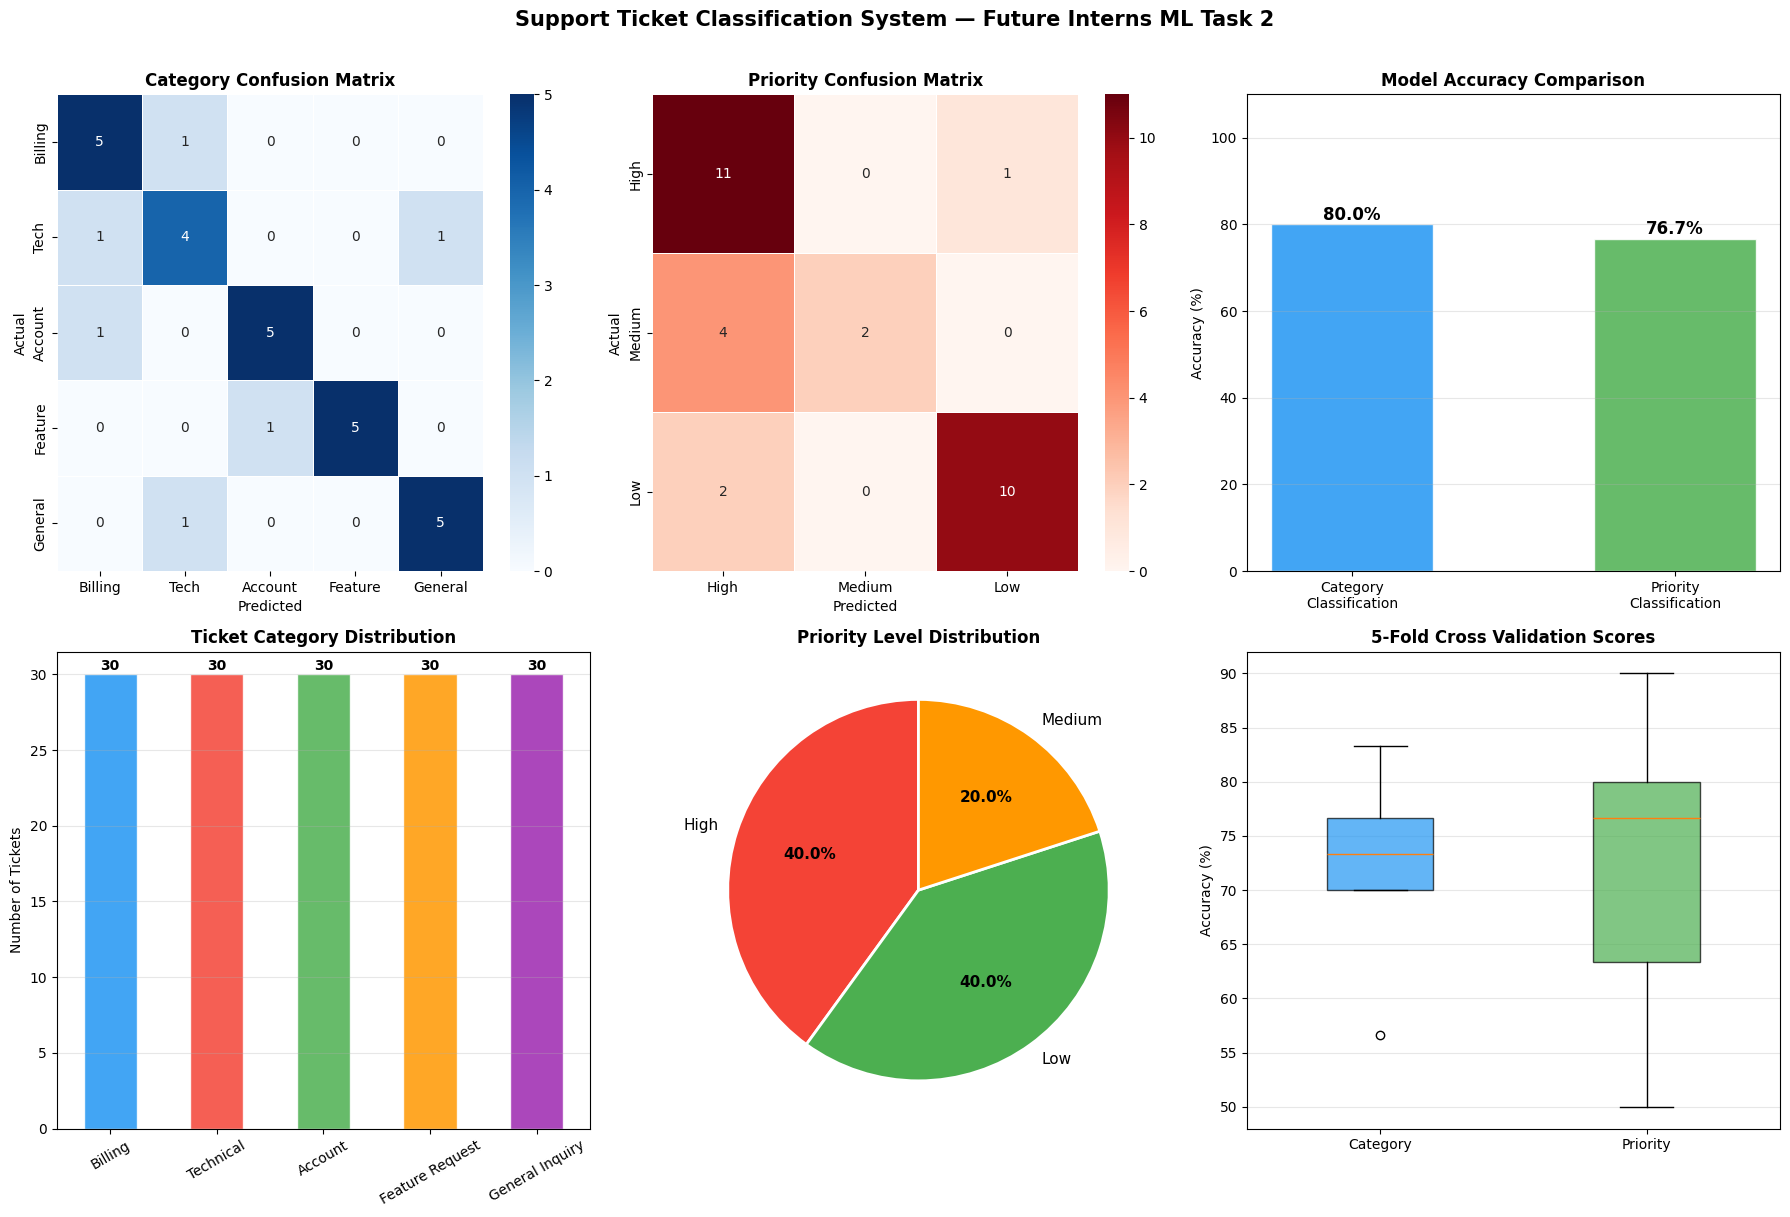

✅ All 6 charts saved as ticket_classification.png


In [12]:
# ── VISUALIZATIONS ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Support Ticket Classification System — Future Interns ML Task 2',
             fontsize=15, fontweight='bold', y=1.01)

# Chart 1 — Category confusion matrix
cm_cat = confusion_matrix(y_cat_test, cat_preds,
          labels=['Billing','Technical','Account','Feature Request','General Inquiry'])
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Billing','Tech','Account','Feature','General'],
            yticklabels=['Billing','Tech','Account','Feature','General'],
            ax=axes[0,0], linewidths=0.5)
axes[0,0].set_title('Category Confusion Matrix', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Actual')
axes[0,0].set_xlabel('Predicted')

# Chart 2 — Priority confusion matrix
cm_pri = confusion_matrix(y_pri_test, pri_preds,
          labels=['High','Medium','Low'])
sns.heatmap(cm_pri, annot=True, fmt='d', cmap='Reds',
            xticklabels=['High','Medium','Low'],
            yticklabels=['High','Medium','Low'],
            ax=axes[0,1], linewidths=0.5)
axes[0,1].set_title('Priority Confusion Matrix', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Actual')
axes[0,1].set_xlabel('Predicted')

# Chart 3 — Model accuracy comparison
models = ['Category\nClassification', 'Priority\nClassification']
accuracies = [cat_acc*100, pri_acc*100]
colors = ['#2196F3', '#4CAF50']
bars = axes[0,2].bar(models, accuracies, color=colors, alpha=0.85,
                      edgecolor='white', width=0.5)
axes[0,2].set_ylim(0, 110)
axes[0,2].set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0,2].set_ylabel('Accuracy (%)')
axes[0,2].grid(alpha=0.3, axis='y')
for bar, acc in zip(bars, accuracies):
    axes[0,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{acc:.1f}%', ha='center', fontweight='bold', fontsize=12)

# Chart 4 — Category distribution
cat_counts = df['category'].value_counts()
cat_colors = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0']
cat_counts.plot(kind='bar', ax=axes[1,0], color=cat_colors,
                alpha=0.85, edgecolor='white')
axes[1,0].set_title('Ticket Category Distribution', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Number of Tickets')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].grid(alpha=0.3, axis='y')
for i, v in enumerate(cat_counts):
    axes[1,0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# Chart 5 — Priority pie chart
priority_colors = {'High': '#F44336', 'Medium': '#FF9800', 'Low': '#4CAF50'}
priority_counts = df['priority'].value_counts()
wedges, texts, autotexts = axes[1,1].pie(
    priority_counts.values,
    labels=priority_counts.index,
    colors=[priority_colors[p] for p in priority_counts.index],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for autotext in autotexts:
    autotext.set_fontweight('bold')
axes[1,1].set_title('Priority Level Distribution', fontsize=12, fontweight='bold')

# Chart 6 — Cross validation scores
cv_cat_scores = cross_val_score(cat_pipeline, X, y_cat, cv=5) * 100
cv_pri_scores = cross_val_score(pri_pipeline, X, y_pri, cv=5) * 100
positions = [1, 2]
bp = axes[1,2].boxplot([cv_cat_scores, cv_pri_scores],
                        positions=positions, patch_artist=True,
                        widths=0.4)
bp['boxes'][0].set_facecolor('#2196F3')
bp['boxes'][1].set_facecolor('#4CAF50')
for box in bp['boxes']:
    box.set_alpha(0.7)
axes[1,2].set_xticks(positions)
axes[1,2].set_xticklabels(['Category', 'Priority'])
axes[1,2].set_title('5-Fold Cross Validation Scores', fontsize=12, fontweight='bold')
axes[1,2].set_ylabel('Accuracy (%)')
axes[1,2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('C:/Users/ganes/OneDrive/Desktop/ticket_classification.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ All 6 charts saved as ticket_classification.png")

In [13]:
# ── LIVE TICKET CLASSIFIER DEMO ───────────────────────────────────────────────
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def classify_ticket(text):
    cleaned = preprocess_text(text)
    category = cat_pipeline.predict([cleaned])[0]
    priority = pri_pipeline.predict([cleaned])[0]
    cat_conf = cat_pipeline.predict_proba([cleaned]).max() * 100
    pri_conf = pri_pipeline.predict_proba([cleaned]).max() * 100
    priority_emoji = {'High': '🔴', 'Medium': '🟡', 'Low': '🟢'}
    category_emoji = {
        'Billing': '💳', 'Technical': '🔧',
        'Account': '👤', 'Feature Request': '💡',
        'General Inquiry': '❓'
    }
    print(f"\n  📩 {text}")
    print(f"     {category_emoji.get(category,'📌')} Category : {category:<20} ({cat_conf:.1f}% confidence)")
    print(f"     {priority_emoji.get(priority,'⚪')} Priority : {priority:<20} ({pri_conf:.1f}% confidence)")

print("=" * 60)
print("   🎯 LIVE TICKET CLASSIFICATION DEMO")
print("=" * 60)

test_tickets = [
    "My payment was charged twice please refund immediately",
    "App keeps crashing when I upload files urgent help needed",
    "How do I change my account password",
    "Can you please add dark mode to the application",
    "What are your support hours and contact details",
    "Server is completely down affecting all our customers",
    "I need to update my billing information",
    "Would love to see better reporting features added",
    "Cannot login since this morning urgent",
    "Please add integration with Google Drive",
]

for ticket in test_tickets:
    classify_ticket(ticket)

# ── BUSINESS IMPACT SUMMARY ───────────────────────────────────────────────────
print("\n" + "=" * 60)
print("   📊 BUSINESS IMPACT SUMMARY")
print("=" * 60)

high_tickets   = len(df[df['priority'] == 'High'])
medium_tickets = len(df[df['priority'] == 'Medium'])
low_tickets    = len(df[df['priority'] == 'Low'])

print(f"\n  🔴 High Priority   : {high_tickets} tickets ({high_tickets/len(df)*100:.1f}%) → Respond within 1 hour")
print(f"  🟡 Medium Priority : {medium_tickets} tickets ({medium_tickets/len(df)*100:.1f}%) → Respond within 24 hours")
print(f"  🟢 Low Priority    : {low_tickets} tickets ({low_tickets/len(df)*100:.1f}%) → Respond within 72 hours")

print(f"\n  📈 Category Accuracy    : {cat_acc*100:.2f}%")
print(f"  📈 Priority Accuracy    : {pri_acc*100:.2f}%")
print(f"  📈 Category CV Score    : {cat_cv*100:.2f}%")
print(f"  📈 Priority CV Score    : {pri_cv*100:.2f}%")
print(f"  📈 Category F1 Score    : {cat_f1:.4f}")
print(f"  📈 Priority F1 Score    : {pri_f1:.4f}")

print(f"\n  💡 Key Insight: {high_tickets} high priority tickets need")
print(f"     immediate attention — {high_tickets/len(df)*100:.0f}% of all incoming tickets!")
print(f"  💡 Feature Requests & General Inquiries ({low_tickets} tickets)")
print(f"     can be handled within 72 hours saving team bandwidth.")
print(f"  💡 This system can auto-route tickets saving ~{len(df)*2} minutes")
print(f"     of manual classification time per {len(df)} tickets!")

print("\n" + "=" * 60)
print("   ✅ TASK 2 COMPLETE!")
print("   Support Ticket Classification System — Ready")
print("   Future Interns — ML Internship | Task 2")
print("=" * 60)

   🎯 LIVE TICKET CLASSIFICATION DEMO

  📩 My payment was charged twice please refund immediately
     💳 Category : Billing              (79.1% confidence)
     🔴 Priority : High                 (80.7% confidence)

  📩 App keeps crashing when I upload files urgent help needed
     🔧 Category : Technical            (27.3% confidence)
     🔴 Priority : High                 (51.3% confidence)

  📩 How do I change my account password
     👤 Category : Account              (66.9% confidence)
     🟡 Priority : Medium               (68.6% confidence)

  📩 Can you please add dark mode to the application
     💡 Category : Feature Request      (74.7% confidence)
     🟢 Priority : Low                  (81.9% confidence)

  📩 What are your support hours and contact details
     ❓ Category : General Inquiry      (57.1% confidence)
     🟢 Priority : Low                  (74.6% confidence)

  📩 Server is completely down affecting all our customers
     🔧 Category : Technical            (56.8% confiden